# Proyek Klasifikasi Gambar: Penyakit Pada Tanaman
- **Nama:** Julianda Putra Mansur
- **Email:** Julianda084@gmail.com
- **ID Dicoding:** haikal1210

## Import Semua Packages/Library yang Digunakan

In [1]:
import os, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm.notebook import tqdm as tq
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, MaxPool2D
from sklearn.metrics import classification_report, confusion_matrix


## Data Preparation

### Data Loading

In [2]:
!kaggle datasets download -d emmarex/plantdisease
!unzip plantdisease.zip

Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d

In [3]:
# Parameter
DATA_DIR = "/content/plantvillage/PlantVillage"
file_paths = []
labels = []

# Iterasi folder untuk mengambil path dan label
for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            file_paths.append(os.path.join(class_path, img_name))
            labels.append(class_name)

df = pd.DataFrame({'path': file_paths, 'labels': labels})
print(f"Total gambar: {len(df)}")
print(df['labels'].value_counts()) # Cek distribusi 15 kelas

Total gambar: 20639
labels
Tomato__Tomato_YellowLeaf__Curl_Virus          3209
Tomato_Bacterial_spot                          2127
Tomato_Late_blight                             1909
Tomato_Septoria_leaf_spot                      1771
Tomato_Spider_mites_Two_spotted_spider_mite    1676
Tomato_healthy                                 1591
Pepper__bell___healthy                         1478
Tomato__Target_Spot                            1404
Potato___Early_blight                          1000
Potato___Late_blight                           1000
Tomato_Early_blight                            1000
Pepper__bell___Bacterial_spot                   997
Tomato_Leaf_Mold                                952
Tomato__Tomato_mosaic_virus                     373
Potato___healthy                                152
Name: count, dtype: int64


### Data Preprocessing

#### Split Dataset

In [4]:
# Split dataset
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['labels'])

df_train['set'] = 'train'
df_test['set'] = 'test'
df_all = pd.concat([df_train, df_test], ignore_index=True)

### Buat Struktur Direktori dan Salin Gambar

In [5]:
output_base_dir = "Dataset-Final"

# Buat folder train
train_output_dir = os.path.join(output_base_dir, 'train')
for class_name in df_train['labels'].unique():
    os.makedirs(os.path.join(train_output_dir, class_name), exist_ok=True)

# Salin gambar untuk training
print("Menyalin gambar untuk training...")
for index, row in tq(df_train.iterrows(), total=len(df_train)):
    src_path = row['path']
    label = row['labels']
    dest_dir = os.path.join(train_output_dir, label)
    shutil.copy(src_path, dest_dir)
print("Penyalinan gambar training selesai.")

# Buat folder test
test_output_dir = os.path.join(output_base_dir, 'test')
for class_name in df_test['labels'].unique():
    os.makedirs(os.path.join(test_output_dir, class_name), exist_ok=True)

# Salin gambar untuk testing
print("Menyalin gambar untuk testing...")
for index, row in tq(df_test.iterrows(), total=len(df_test)):
    src_path = row['path']
    label = row['labels']
    dest_dir = os.path.join(test_output_dir, label)
    shutil.copy(src_path, dest_dir)
print("Penyalinan gambar testing selesai.")

Menyalin gambar untuk training...


  0%|          | 0/16511 [00:00<?, ?it/s]

Penyalinan gambar training selesai.
Menyalin gambar untuk testing...


  0%|          | 0/4128 [00:00<?, ?it/s]

Penyalinan gambar testing selesai.


In [6]:
#data augmented

import cv2
import numpy as np
import random
from skimage import io, img_as_ubyte
from skimage.transform import rotate, AffineTransform, warp
from skimage.exposure import adjust_gamma

# Rotasi Berlawanan Arah Jarum Jam
def anticlockwise_rotation(img):
    img = cv2.resize(img, (150, 150))
    sudut = random.randint(0, 180)
    return rotate(img, sudut)

# Rotasi Searah Jarum Jam
def clockwise_rotation(img):
    img = cv2.resize(img, (150, 150))
    sudut = random.randint(0, 180)
    return rotate(img, -sudut)

# Flip Vertikal (Atas-Bawah)
def flip_up_down(img):
    img = cv2.resize(img, (150, 150))
    return np.flipud(img)

# Penyesuaian Kecerahan (Brightness)
def add_brightness(img):
    img = cv2.resize(img, (150, 150))
    # Menggunakan Gamma Correction untuk kecerahan
    return adjust_gamma(img, gamma=0.5, gain=1)

# Efek Blur
def blur_image(img):
    img = cv2.resize(img, (150, 150))
    return cv2.GaussianBlur(img, (9, 9), 0)

#  Pergeseran Melengkung (Warp Shift)
def warp_shift(img):
    img = cv2.resize(img, (150, 150))
    transform = AffineTransform(translation=(0, 40))
    return warp(img, transform, mode="wrap")

# Menyimpan semua fungsi ke dalam dictionary
transformations = {
    'rotate anticlockwise': anticlockwise_rotation,
    'rotate clockwise': clockwise_rotation,
    'warp shift': warp_shift,
    'blurring image': blur_image,
    'add brightness': add_brightness,
    'flip up down': flip_up_down
}

In [7]:
import os

# Path folder training yang berisi 15 kelas
train_path = "Dataset-Final/train/"

# Iterasi untuk setiap folder kelas (15 kelas)
for class_name in os.listdir(train_path):
    class_dir = os.path.join(train_path, class_name)

    if not os.path.isdir(class_dir):
        continue

    # Ambil semua daftar file gambar di kelas tersebut
    images = [os.path.join(class_dir, im) for im in os.listdir(class_dir)
              if im.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Tentukan berapa banyak gambar augmented yang ingin dihasilkan per kelas
    images_to_generate = 500
    i = 1

    print(f"Memulai augmentasi untuk kelas: {class_name}...")

    while i <= images_to_generate:
        image_path = random.choice(images)
        try:
            # Membaca gambar asli
            original_image = io.imread(image_path)

            # Konversi ke float32 untuk stabilitas
            image_to_transform = original_image.astype('float32') / 255.0

            # Tentukan berapa banyak transformasi yang ditumpuk (Sequential)
            num_transformations_to_apply = random.randint(1, len(transformations))

            n = 0
            while n < num_transformations_to_apply:
                key = random.choice(list(transformations))
                image_to_transform = transformations[key](image_to_transform)
                n += 1

            # Nama file baru
            new_image_path = os.path.join(class_dir, f"aug_{class_name}_{i}.jpg")

            # Kembalikan ke format 8-bit (0-255)
            final_image = img_as_ubyte(np.clip(image_to_transform, 0, 1))

            # Konversi RGB ke BGR jika menggunakan OpenCV untuk menyimpan
            if len(final_image.shape) == 3:
                final_image = cv2.cvtColor(final_image, cv2.COLOR_RGB2BGR)

            cv2.imwrite(new_image_path, final_image)
            i += 1

        except Exception as e:
            print(f"Error pada {image_path}: {e}")

print("Selesai! Seluruh kelas telah berhasil diperbanyak dengan data augmented.")

Memulai augmentasi untuk kelas: Pepper__bell___healthy...
Memulai augmentasi untuk kelas: Potato___Early_blight...
Memulai augmentasi untuk kelas: Tomato_healthy...
Memulai augmentasi untuk kelas: Potato___Late_blight...
Memulai augmentasi untuk kelas: Tomato__Target_Spot...
Memulai augmentasi untuk kelas: Tomato_Septoria_leaf_spot...
Memulai augmentasi untuk kelas: Tomato_Bacterial_spot...
Memulai augmentasi untuk kelas: Tomato__Tomato_mosaic_virus...
Memulai augmentasi untuk kelas: Tomato__Tomato_YellowLeaf__Curl_Virus...
Memulai augmentasi untuk kelas: Pepper__bell___Bacterial_spot...
Memulai augmentasi untuk kelas: Tomato_Leaf_Mold...
Memulai augmentasi untuk kelas: Potato___healthy...
Memulai augmentasi untuk kelas: Tomato_Early_blight...
Memulai augmentasi untuk kelas: Tomato_Spider_mites_Two_spotted_spider_mite...
Memulai augmentasi untuk kelas: Tomato_Late_blight...
Selesai! Seluruh kelas telah berhasil diperbanyak dengan data augmented.


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Gunakan direktori Dataset-Final yang sudah diperbanyak datanya
TRAIN_DIR = "Dataset-Final/train/"

# Persiapan Generator (Hanya rescale, karena augmentasi sudah dilakukan secara fisik)
datagen = ImageDataGenerator(
    rescale=1/255.,
    validation_split=0.2
)

# Load data Training
train_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Load data Validation
validation_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 19213 images belonging to 15 classes.
Found 4797 images belonging to 15 classes.


## Modelling

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPool2D, Flatten, Dense, Dropout

model_1 = Sequential([
    # Blok Konvolusi 1
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150, 150, 3)),
    BatchNormalization(),
    MaxPool2D((2, 2)),

    # Blok Konvolusi 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D((2, 2)),

    # Blok Konvolusi 3
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D((2, 2)),

    # Layer Fully Connected
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5), # Mencegah overfitting
    Dense(15, activation='softmax') # Output untuk 15 kelas penyakit
])

model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
#Callback untuk Target Akurasi 95%
class MyCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') >= 0.97 and logs.get('val_accuracy') >= 0.95):
            print("\nTarget Akurasi 95% tercapai, menghentikan training!")
            self.model.stop_training = True

In [13]:
history = model_1.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[MyCallback()]
)

Epoch 1/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.3143 - loss: 2.3887 - val_accuracy: 0.5178 - val_loss: 1.9318
Epoch 2/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.4052 - loss: 1.8677 - val_accuracy: 0.4797 - val_loss: 1.9235
Epoch 3/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.4481 - loss: 1.6901 - val_accuracy: 0.7061 - val_loss: 0.9413
Epoch 4/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.4958 - loss: 1.5198 - val_accuracy: 0.5349 - val_loss: 2.0269
Epoch 5/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.5241 - loss: 1.4230 - val_accuracy: 0.5305 - val_loss: 1.4583
Epoch 6/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.5639 - loss: 1.3230 - val_accuracy: 0.5881 - val_loss: 2.0745
Epoch 7/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.5975 - loss: 1.2055 - val_accuracy: 0.5758 - val_loss: 1.7507
Epoch 8/50
601/601 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.6334 - loss: 1.0962 - 

## Evaluasi dan Visualisasi

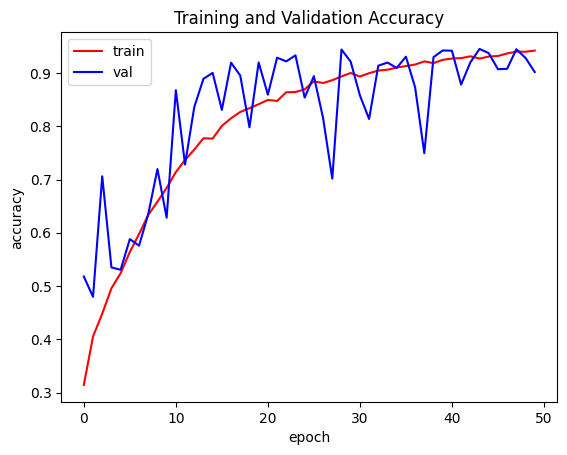

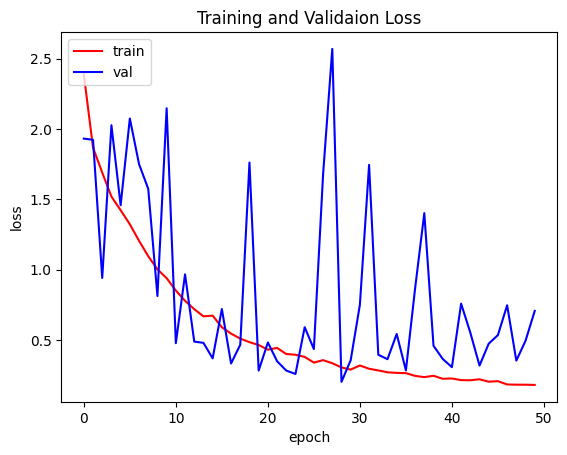

In [15]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

In [16]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    "Dataset-Final/test/",
    target_size=(150, 150),
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

# Prediksi
preds = model_1.predict(test_generator)
y_pred = np.argmax(preds, axis=1)

# Tampilkan Laporan Klasifikasi
from sklearn.metrics import classification_report
print(classification_report(test_generator.classes, y_pred, target_names=list(test_generator.class_indices.keys())))

Found 4128 images belonging to 15 classes.
4128/4128 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.94      0.96       199
                     Pepper__bell___healthy       0.95      1.00      0.97       296
                      Potato___Early_blight       0.92      0.97      0.95       200
                       Potato___Late_blight       0.96      0.89      0.92       200
                           Potato___healthy       0.82      0.60      0.69        30
                      Tomato_Bacterial_spot       0.95      0.99      0.97       426
                        Tomato_Early_blight       0.85      0.90      0.87       200
                         Tomato_Late_blight       0.92      0.92      0.92       382
                           Tomato_Leaf_Mold       0.85      0.91      0.88       190
                  Tomato_Septoria_leaf_spot       0.97      0.

## Konversi Model

In [18]:
# Tentukan path penyimpanan
export_dir = 'saved_model/plant_disease_model'

# Simpan model (SavedModel format) menggunakan model.export()
model_1.export(export_dir)

print(f"Model berhasil disimpan di: {export_dir}")

Saved artifact at 'saved_model/plant_disease_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_18')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  139336483475280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139336483475856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139336483476240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139336483477200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139336483477008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139336483476432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139336483476816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139336483476048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139336483475472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139336483478352: TensorSpec(shape=(), dtype=tf.resource, name=Non

In [19]:
import tensorflow as tf

# Inisialisasi converter dari SavedModel
converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)

# Optimasi untuk memperkecil ukuran file (Quantization)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Lakukan konversi
tflite_model = converter.convert()

# Simpan hasil konversi ke file .tflite
with open('model_tanaman.tflite', 'wb') as f:
    f.write(tflite_model)

print("Model TF-Lite berhasil dibuat: model_tanaman.tflite")

Model TF-Lite berhasil dibuat: model_tanaman.tflite


In [36]:
# Ambil daftar nama kelas dari generator yang Anda gunakan saat training
labels = sorted(list(train_generator.class_indices.keys()))

# Simpan ke dalam file label.txt
with open('label.txt', 'w') as f:
    for label in labels:
        f.write(label + '\n')

print("File label.txt berhasil dibuat!")

File label.txt berhasil dibuat!


In [20]:
# Jalankan ini di cell baru untuk menginstal library konversi
!pip install tensorflowjs

INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 9.6 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.46.3
    Uninstalling wheel-0.46.3:
      Successfully uninstalled wheel-0.46.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.5.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.41.0 requires pack

In [21]:
import os

# Buat folder untuk hasil TFJS
tfjs_target_dir = 'model_tfjs'
if not os.path.exists(tfjs_target_dir):
    os.makedirs(tfjs_target_dir)

# Jalankan command konversi
!tensorflowjs_converter --input_format=tf_saved_model {export_dir} {tfjs_target_dir}

print(f"Model TFJS berhasil disimpan di folder: {tfjs_target_dir}")

2026-04-25 16:53:34.497434: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777136014.531892   36367 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777136014.542981   36367 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777136014.568816   36367 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777136014.568856   36367 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777136014.568868   36367 computation_placer.cc:177] computation placer alr

## Inference (Optional)

In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

#Muat kembali model yang sudah disimpan
model_path = 'saved_model/plant_disease_model'
# Menggunakan TFSMLayer untuk memuat SavedModel di Keras 3
loaded_model = tf.keras.layers.TFSMLayer(model_path, call_endpoint='serve')

# Daftar label kelas (pastikan urutannya sama dengan saat training)
class_names = list(train_generator.class_indices.keys())
print("Model berhasil dimuat. Siap melakukan prediksi!")

Model berhasil dimuat. Siap melakukan prediksi!


In [28]:
def predict_plant_disease(img_path):
    # Load gambar
    img = image.load_img(img_path, target_size=(150, 150))

    # Ubah gambar ke array dan normalisasi (rescale 1/255)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Tambah dimensi batch
    img_array /= 255.0

    # Lakukan Prediksi
    predictions = loaded_model(img_array)
    score = tf.nn.softmax(predictions[0]) # Mengambil probabilitas

    # Ambil hasil tertinggi
    predicted_class = class_names[np.argmax(predictions)]
    confidence = 100 * np.max(predictions)

    # Tampilkan Gambar dan Hasil
    plt.imshow(img)
    plt.title(f"Prediksi: {predicted_class} \nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

    return predicted_class, confidence

In [32]:
from google.colab import files
from tensorflow.keras.preprocessing import image

# Upload file gambar
uploaded = files.upload()

for fn in uploaded.keys():
  img_path = fn
  print(f'User mengunggah file "{fn}" untuk diprediksi.')

Saving paper.jpeg to paper.jpeg
User mengunggah file "paper.jpeg" untuk diprediksi.


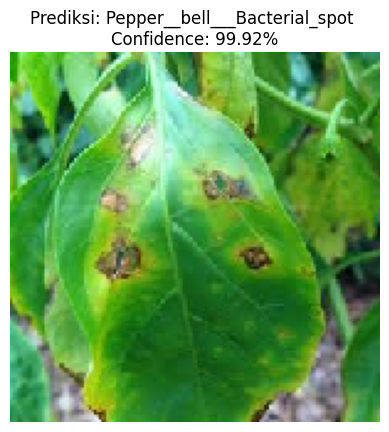

('Pepper__bell___Bacterial_spot', np.float32(99.91714))

In [33]:
predict_plant_disease(img_path)